# Writing GPU Kernels with KernelAbstractions.jl

This tutorial introduces [KernelAbstractions.jl](https://github.com/JuliaGPU/KernelAbstractions.jl) (KA),
a Julia package that lets you write GPU-style kernels that run on any backend:
NVIDIA (CUDA.jl), AMD (AMDGPU.jl), Apple (Metal.jl), Intel (oneAPI.jl), or plain CPU.

You don't need to understand GPU hardware in detail to follow along.
If you've written a `for` loop in Julia, you have everything you need.

Source code: [github.com/cwittens/A\_KernelAbstractions\_Tutorial](https://github.com/cwittens/A_KernelAbstractions_Tutorial)

The only mental model you need for now (simplified): a GPU runs thousands of
work items at once, and the hardware groups them into small bundles that
execute **in lockstep**. Every work item in a bundle runs the same instruction
at the same time. If some finish early (e.g. a short loop), they sit idle
and wait for the slowest one in their bundle to catch up. We'll come back
to why this matters at the end.

## Setup

In [1]:
using KernelAbstractions
using CUDA
using Adapt

backend = CUDABackend();

If you don't have an NVIDIA GPU, you can use `CPU()` instead,
or `ROCBackend()`, `MetalBackend()`, `oneAPIBackend()` depending on your hardware.
Everything in this tutorial works the same way regardless of backend.

One caveat: Apple's Metal does not support `Float64`. If you're on a Mac using
`MetalBackend()`, use `Float32` for all your arrays, e.g.
`A = rand(Float32, 100_000)` instead of `A = rand(100_000)`.
The kernels themselves don't change, only the element types of your data.

## Part 1: Starting from CPU loops

Let's say we want to multiply every element of a vector by 2.
On the CPU, the natural Julia way is broadcasting:

In [2]:
A = rand(100_000);
A .= A .* 2;

Broadcasting is perfectly fine and you should use it when you can!
But for the sake of this tutorial, let's write it as an explicit `for` loop,
because that's closer to what a GPU kernel looks like:

In [3]:
A = rand(100_000);
for i in eachindex(A)
    A[i] *= 2
end
maximum(A)

1.9999962330725658

This works perfectly on normal Julia arrays. But what happens when we try
to run a loop like this on GPU data?

## Part 2: Why loops don't work on the GPU

Let's first move our array to the GPU using `adapt`.
`adapt` converts a CPU array to whatever array type the backend uses.
On CUDA, that's a `CuArray`. On CPU, it's just a regular `Array`.

In [4]:
A_adapted = adapt(backend, rand(100_000));
typeof(A_adapted)

CUDA.CuArray{Float64, 1, CUDA.DeviceMemory}

The array now lives on the GPU and if we try our `for` loop on this GPU array, it fails:

```julia
for i in eachindex(A_adapted)
    A_adapted[i] *= 2   # ERROR: Scalar indexing is disallowed
end
```

This error is intentional. Accessing GPU memory one element at a time from the
CPU is extremely slow. Instead,
we need to tell the GPU to execute the operation in parallel, where each work
item handles one (or a few) elements. That's basically what a **kernel** is.

If you really need to access a single element of a GPU array (e.g. for
debugging), you can use `@allowscalar` from `GPUArraysCore`:

```julia
using GPUArraysCore: @allowscalar
@allowscalar A_adapted[1]
```

Note: broadcasting *does* work on GPU arrays (`A_adapted .= A_adapted .* 2`) because
GPUArrays.jl implements it as a kernel behind the scenes. In fact, most standard
library functions just work on GPU arrays too: `sum`, `mean`, `std`, `cumsum`,
`map`, `reduce`, `maximum`, and many more. Each of these launches its own GPU
kernel under the hood. This works thanks to Julia's multiple dispatch:
`sum(cpu_array)` and `sum(gpu_array)` call different methods, and the GPU
method knows how to launch a kernel. You should only write a custom kernel
when you have logic that these built-in operations can't express.

## Part 3: Your first kernel

A kernel is a function that gets executed once per "work item" (think: one
iteration of your loop). Each work item gets a unique index and uses it
to know which element to work on.

Here is the `for` loop from above, rewritten as a KA kernel:

In [5]:
@kernel function mul2_kernel!(A)
    i = @index(Global)
    A[i] *= 2
end

mul2_kernel! (generic function with 4 methods)

Let's unpack this:

- **`@kernel`** marks this function as a kernel. It's not a normal function anymore.
  It describes what *one work item* does.
- **`@index(Global)`** gives this work item its unique index. If we launch 100,000
  work items, each one gets a different `i` from 1 to 100,000.

A kernel doesn't return anything. It modifies arrays in-place.

### Launching a kernel

Launching a kernel is a two-step process:

1. **Create a callable kernel** by passing a backend. This doesn't run anything
   yet, it just tells KA which device to compile for:

In [6]:
mul2 = mul2_kernel!(backend);

2. **Call it** with your arguments and an `ndrange`:

In [7]:
A_adapted = adapt(backend, rand(100000))
mul2(A_adapted, ndrange=size(A_adapted))

The `ndrange` ("iteration range") tells KA how many work items to launch.
For a 1D array, this is typically `size(A)` or `length(A)`.
Each work item gets assigned one index from 1 to `length(A)`.

Let's verify it worked:

In [8]:
maximum(A_adapted)

1.9999517140182024

## Part 4: 2D indexing

For matrices and higher-dimensional arrays, use `@index(Global, NTuple)` to
get a tuple of indices:

In [9]:
@kernel function mul2_matrix_kernel!(B)
    i, j = @index(Global, NTuple)
    B[i, j] *= 2
end

mul2_matrix_kernel! (generic function with 4 methods)

For 1D arrays, `@index(Global)` (without `NTuple`) returns a single integer.
For 2D and higher, use `NTuple` to get the tuple. (It also works for 1D
if you like consistency.) If you forget it, you could get an illegal memory access error!

In [10]:
B = rand(1000, 100)
B_adapted = adapt(backend, B)

mul2_matrix = mul2_matrix_kernel!(backend)
mul2_matrix(B_adapted, ndrange=size(B_adapted))

maximum(B_adapted)

1.9999870525149586

The `ndrange` here is `size(B)` which is `(1000, 100)`. KA launches
1000 x 100 = 100,000 work items, each getting a unique `(i, j)` pair.

## Part 5: A copy kernel, `@Const`, and `@inbounds`

Let's write a kernel that copies one array into another. This introduces
two new things:

**`@Const`** tells the compiler that an argument is read-only and won't be
modified by any work item. This extra information allows the compiler to
optimize memory access. The rule is simple: if a kernel argument is
*never written to*, mark it `@Const`.

**`@inbounds`** skips bounds checking for performance, just like in regular Julia.

**Warning:** using `@inbounds` is a promise to the compiler that all array
accesses are valid. If you get the indexing wrong, you won't get a helpful
error message. Instead, you may get silently wrong results, crashes, or
segfaults. Only add `@inbounds` once you're confident your indexing is correct.

For longer kernels where sprinkling `@inbounds` on every line gets tedious,
you can apply it to the entire kernel at once:

```julia
@kernel inbounds=true function my_long_kernel!(A, B, C)
    i = @index(Global)
    A[i] = B[i] + C[i]  ## no @inbounds needed, applied to the whole kernel
end
```

In [11]:
@kernel function copy_kernel!(A, @Const(B))
    i = @index(Global)
    @inbounds A[i] = B[i]
end

copy_kernel! (generic function with 4 methods)

when you dont want to instantiate an array on the CPU and then move it to the GPU, you can directly allocate on the GPU using `KernelAbstractions.zeros`.

In [12]:
A = KernelAbstractions.zeros(backend, Float64, 10_000)
B = adapt(backend, collect(1:10_000))

my_copy = copy_kernel!(get_backend(A))
my_copy(A, B, ndrange=length(A))

A == B

true

Here we also used `get_backend(A)` instead of passing `backend` directly. `get_backend` retrieves the backend from an existing array.

## Part 6: Putting it together: the Mandelbrot set

Let's do something visual. The Mandelbrot set is a perfect GPU problem:
each pixel is computed independently, and there's a lot of arithmetic to do.

In [13]:
@kernel function mandelbrot_kernel!(img, @Const(xs), @Const(ys), maxiter)
    i, j = @index(Global, NTuple)

    c = complex(xs[j], ys[i])
    z = c
    iter = 0

    while abs2(z) <= 4 && iter < maxiter
        z = z * z + c
        iter += 1
    end

    @inbounds img[i, j] = iter
end

mandelbrot_kernel! (generic function with 4 methods)

Now let's run it and time it. Note that the first call to a kernel includes
compilation time (just like any Julia function). The second call gives
you the true runtime:

In [14]:
function mandelbrot(backend)
    # Parameters for the Mandelbrot image
    Nx, Ny = 8000, 6000
    maxiter = 512

    xs = adapt(backend, range(-2.0, 0.7, length=Nx))
    ys = adapt(backend, range(-1.2, 1.2, length=Ny))
    img = KernelAbstractions.zeros(backend, Int, Ny, Nx)

    kernel = mandelbrot_kernel!(backend)
    kernel(img, xs, ys, maxiter, ndrange=size(img))

    return Array(img)  ## move back to CPU for visualization
end

# let it compile first
mandelbrot(CPU());
mandelbrot(CUDABackend());

@time img_cpu = mandelbrot(CPU());
@time img_cpu = mandelbrot(backend);

 16.996481 seconds (46.94 k allocations: 734.578 MiB, 0.06% gc time)
  0.181483 seconds (433 allocations: 366.226 MiB, 1.40% gc time)


The GPU version is about 100x faster than the CPU version!

Now, for the fun of it, let's visualize the Mandelbrot set:

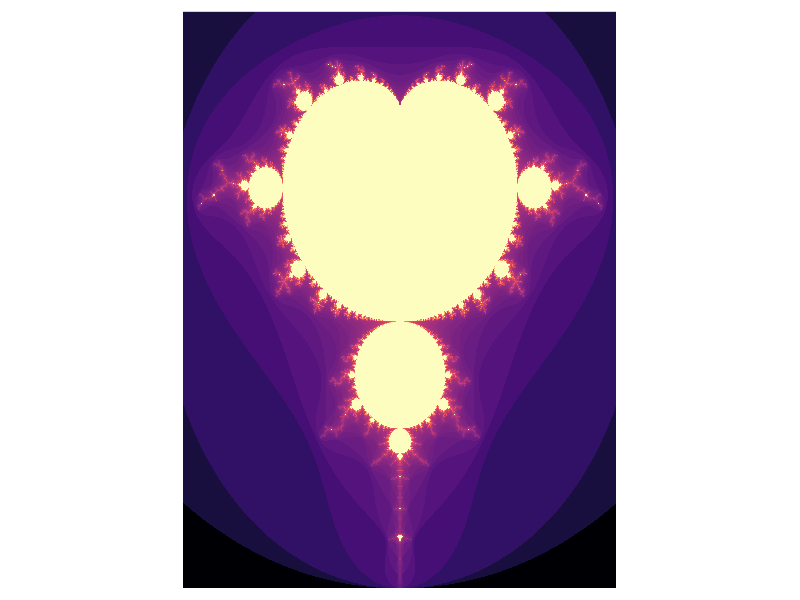

In [15]:
using Plots
heatmap(log.(img_cpu .+ 1)', c=:magma, aspect_ratio=1,
    axis=false, ticks=false, colorbar=false, size=(800, 600))

### A note on lockstep execution and the Mandelbrot kernel

Remember the mental model from the introduction: work items are grouped into
bundles that execute in lockstep. Now look at the `while` loop in our
Mandelbrot kernel. Pixels outside the set bail out after a few iterations,
while pixels near the boundary may need all 512. But since all work items in a
bundle execute together, the fast ones (outside the set) sit idle waiting for
the slowest one (on the boundary) to finish its loop.

These bundles are called **warps** on NVIDIA and **wavefronts** on AMD, and
this slowdown is known as **warp divergence**. You could try to work around it
by reordering pixels so that work items with similar iteration counts end up in
the same bundle. But this kind of optimization is very problem-specific and
adds a lot of complexity.

The good news: even with this inefficiency, just naively putting the
Mandelbrot computation on a GPU gives you roughly a 100x speedup over a
single CPU core. Most of the performance gain comes from the sheer
parallelism, not from clever scheduling. Optimize later, if you need to.

## Part 7: Miscellaneous

### A note on `CUDA.@time`

When just benchmarking a kernel, as in `kernel(img, xs, ys, maxiter, ndrange=size(img))`
use `CUDA.@time` instead of `@time` because kernel launches are
**asynchronous**: the launch returns immediately, before the kernel has
finished executing. `@time` would only measure the launch overhead
(a few microseconds), not the actual compute time.
`CUDA.@time` includes a device synchronization so you get the real time.

This is not a problem when measuring the whole `mandelbrot` function, because `Array(img)` synchronizes.

### Profiling

For more detailed performance analysis on NVIDIA GPUs, CUDA.jl provides
`CUDA.@profile`, which shows you exactly how long each kernel takes on the
device, how much time is spent on API calls, etc:

```julia
CUDA.@profile begin
    kernel(img, xs, ys, maxiter, ndrange=size(img))
end
```

This is extremely useful once you start optimizing. Note that profiling
tools are backend-specific: AMD's AMDGPU.jl does not yet have an equivalent
built-in profiler. There is an
[open PR](https://github.com/JuliaGPU/AMDGPU.jl/pull/695) to add one based
on `rocprof`. Contributions welcome!
If you're developing on AMD but want to profile, one pragmatic (if not ideal)
option is to profile on CUDA first and then switch backends for production,
since KA kernels are portable.

### One last practical Tip
The error messages in KA can be quite cryptic, especially when using a GPU backend. If you get an error message you don't understand, try switching to the `CPU()` backend. However, some problems (like using global variables in your kernel) will not show up as errors on the CPU but will fail on the GPU.

## Summary

Here's everything you need to write simple portable GPU kernels:

1. **Pick a backend**: `backend = CUDABackend()` (or `CPU()`, `ROCBackend()`, ...)
2. **Move your data**: `A_adapted = adapt(backend, A_cpu)`
3. **Know the backend**: `get_backend(C)` to retrieve the backend from an array
3. **Write a kernel** with `@kernel function my_kernel!(args...) ... end`
4. **Get indices** with `@index(Global, NTuple)`
5. **Mark read-only args** with `@Const`
6. **Create a callable** with `kernel = my_kernel!(backend)`
7. **Launch** with `kernel(args..., ndrange=size(A))`
8. **Get results back onto the CPU** with `Array(A_adapted)`

That's it. You can now write kernels that run on CPUs, NVIDIA GPUs, AMD GPUs,
Apple Silicon GPUs, and Intel GPUs, all from the same source code.

### What's next?

Once you're comfortable with the basics, KA offers more advanced features. See the [docs](https://juliagpu.github.io/KernelAbstractions.jl/stable/api/) for details.

But for getting started, the basics above are all you need.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*